# Getting Started with Kompot

**Kompot** finds genes whose expression changes between two conditions at
single-cell resolution. It fits Gaussian-process models over a continuous
cell-state representation and scores each gene with a **Mahalanobis distance**
that accounts for expression covariance, so it detects coordinated, trajectory-aware
changes that per-cluster tests miss.

This front-door tutorial runs **differential expression (DE)** end to end and
visualizes the result. The method and its derivation live in the
[paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769).

**Dive deeper:**
[Advanced DE options](./02_differential_expression_detailed.ipynb) ·
[DE with sample variance](./03_sample_variance.ipynb) ·
[Differential abundance](./04_differential_abundance.ipynb)

We compare bone marrow from **Young vs. Old** mice.

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

## Configuration

Everything you would adapt for your own data lives here:

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"                 # condition column in adata.obs
CONDITIONS = ["Young", "Old"]           # first entry is the reference
CELL_TYPE_COLUMN = "highres_celltype"   # for visualization only
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"  # cell-state representation
LAYER_FOR_EXPRESSION = "logged_counts"        # expression layer

## Load Data

The dataset downloads automatically from Zenodo on first run:

In [3]:
import os
from pathlib import Path

import requests
from tqdm.auto import tqdm

Path(DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Downloading dataset (~2.4 GB) from Zenodo ...")
    url = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=1 << 20):
            file.write(chunk)
            bar.update(len(chunk))

adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

A quick look at the cell types and the two conditions:

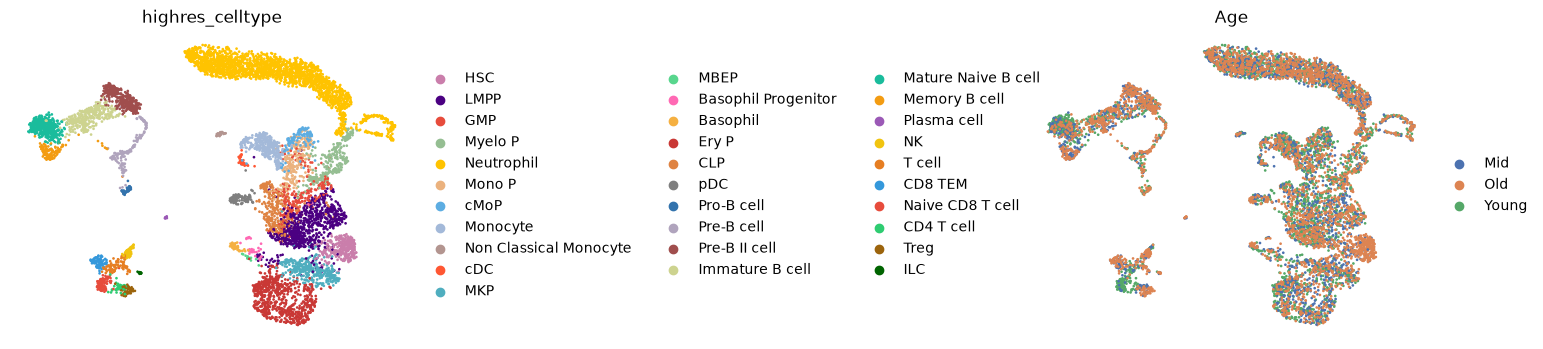

In [4]:
sc.pl.umap(adata, color=[CELL_TYPE_COLUMN, GROUPING_COLUMN], frameon=False, wspace=1.3)

Kompot needs a **continuous** cell-state representation.
[Palantir diffusion maps](https://github.com/dpeerlab/Palantir) capture the geometry
of differentiation while denoising:

In [5]:
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40);

## Differential Expression

One call fits the models, scores every gene, and calibrates an FDR against a null
of shuffled genes. See [`kompot.de`](https://kompot.readthedocs.io/en/latest/simplified.html#kompot.de).

In [6]:
de_results = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),  # 0 = all cells at once; raise for lower memory
)

[2026-07-11 00:55:01,796] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-11 00:55:01,796] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-11 00:55:06,585] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-11 00:55:34,589] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-11 00:56:41,559] [INFO    ] FDR analysis complete: 192/16285 genes significantly DE at FDR < 0.05


[2026-07-11 00:56:41,561] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 5.8215


[2026-07-11 00:56:48,460] [INFO    ] This run will have `run_id=0`.


Results land in `adata.var`. The key columns (for `Young`→`Old`):

- `kompot_de_Young_to_Old_mean_lfc` — mean log fold change
- `kompot_de_Young_to_Old_mahalanobis` — significance (higher = stronger)
- `kompot_de_Young_to_Old_is_de` — significant at FDR < 0.05

In [7]:
c1, c2 = CONDITIONS
mahal = f"kompot_de_{c1}_to_{c2}_mahalanobis"

adata.var.loc[:, adata.var.columns.str.contains("kompot_de")] \
    .sort_values(mahal, ascending=False).head(20)

,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis_local_fdr,kompot_de_Young_to_Old_is_de
H2-Q7,15.224920,0.371810,1.283086e-141,True
Cd74,12.781286,0.105968,1.641235e-80,True
H2-Aa,12.641082,0.142574,2.138046e-77,True
H2-Ab1,12.307942,0.153822,1.587455e-70,True
Igkc,11.416240,0.016244,1.449789e-53,True
H2-Eb1,11.371004,0.123908,8.317497e-53,True
AW112010,11.366238,0.238251,1.114925e-52,True
S100a9,10.385744,-0.051261,5.227253e-37,True
Ifitm3,10.134062,0.110643,1.495802e-33,True
S100a8,10.089391,-0.049699,5.666282e-33,True


### Volcano plot

Effect size vs. significance, one point per gene ([`volcano_de`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.volcano_de)):

[2026-07-11 00:56:49,080] [INFO    ] Found DE run info for run_id=-1


[2026-07-11 00:56:49,081] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-11 00:56:49,081] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-11 00:56:49,083] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-11 00:56:49,084] [INFO    ] Using DE run 0: comparing Young to Old


[2026-07-11 00:56:49,095] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'


[2026-07-11 00:56:49,103] [INFO    ] Highlighting 192 genes marked as DE (109 up, 83 down)


[2026-07-11 00:56:49,119] [INFO    ] Labeling top 10 genes by score


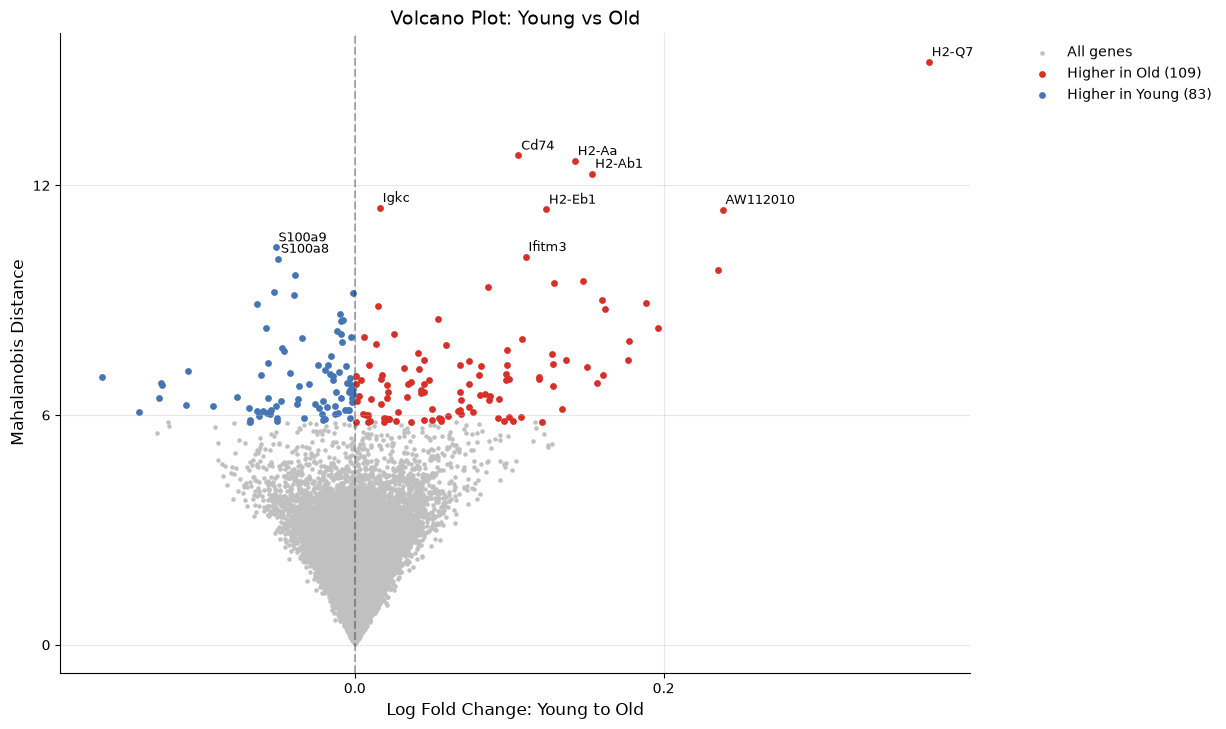

In [8]:
kompot.plot.volcano_de(adata)

Highlight gene sets of interest with custom colors and labels:

[2026-07-11 00:56:49,426] [INFO    ] Found DE run info for run_id=-1


[2026-07-11 00:56:49,426] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-11 00:56:49,427] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-11 00:56:49,428] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-11 00:56:49,429] [INFO    ] Using DE run 0: comparing Young to Old


[2026-07-11 00:56:49,437] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'


[2026-07-11 00:56:49,440] [INFO    ] Added highlight group 'MHC class II' with 4 genes


[2026-07-11 00:56:49,441] [INFO    ] Added highlight group 'Antioxidant' with 5 genes


[2026-07-11 00:56:49,455] [INFO    ] Labeling 9 specific genes


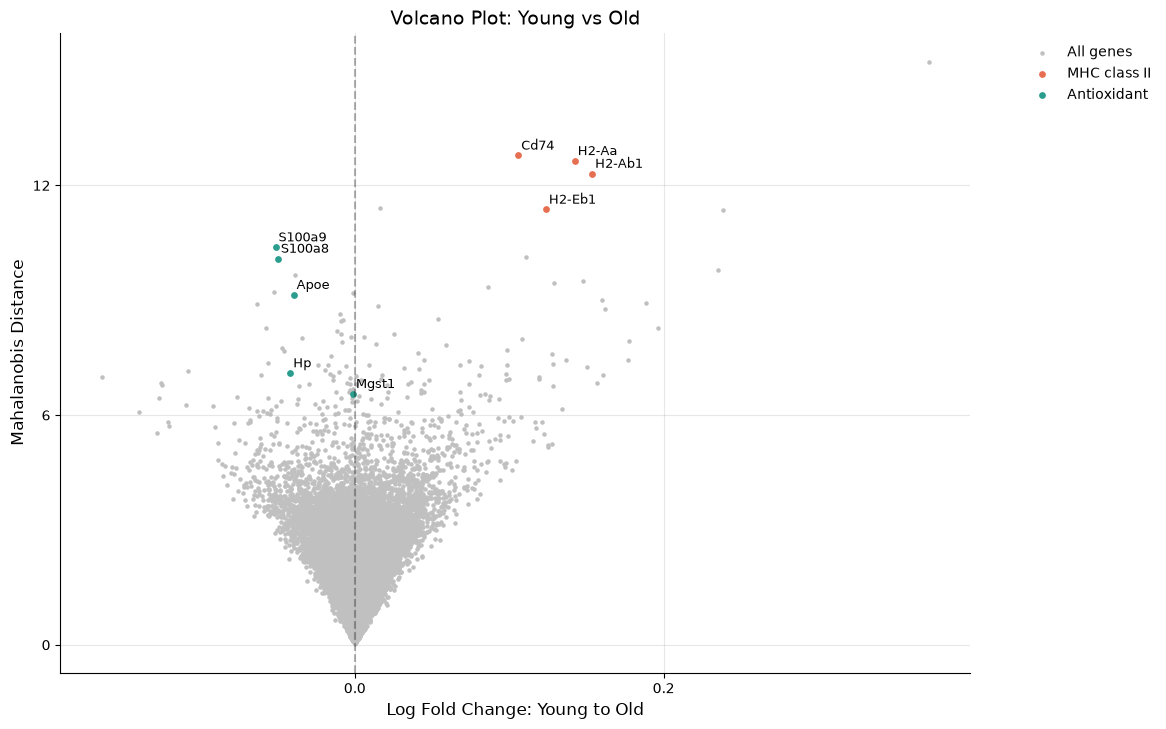

In [9]:
gene_sets = [
    {"name": "MHC class II", "genes": ["H2-Ab1", "H2-Aa", "Cd74", "H2-Eb1"], "color": "#E76F51"},
    {"name": "Antioxidant", "genes": ["S100a8", "S100a9", "Mgst1", "Apoe", "Hp"], "color": "#2A9D8F"},
]
# keep only genes present in this dataset
for gs in gene_sets:
    gs["genes"] = [g for g in gs["genes"] if g in adata.var_names]

kompot.plot.volcano_de(
    adata,
    highlight_genes=gene_sets,
    gene_labels=[g for gs in gene_sets for g in gs["genes"]],
)

### Where the signal sits

Project a top gene's smoothed expression and fold change back onto the UMAP with [`plot_gene_expression`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.plot_gene_expression):

[2026-07-11 00:56:49,733] [INFO    ] Found DE run info for run_id=-1


[2026-07-11 00:56:49,734] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-11 00:56:49,734] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-11 00:56:49,736] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-11 00:56:49,737] [INFO    ] Using DE run 0: comparing Young to Old


[2026-07-11 00:56:49,737] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Old_mean_lfc', score_key: 'kompot_de_Young_to_Old_mahalanobis'


[2026-07-11 00:56:49,738] [INFO    ] Using layer 'logged_counts' inferred from run information


[2026-07-11 00:56:49,741] [INFO    ] Using smoothed layer 'kompot_de_Young_smoothed' for 'Young'


[2026-07-11 00:56:49,741] [INFO    ] Using smoothed layer 'kompot_de_Old_smoothed' for 'Old'


[2026-07-11 00:56:49,742] [INFO    ] Using fold_change layer 'kompot_de_Young_to_Old_fold_change' from run_info


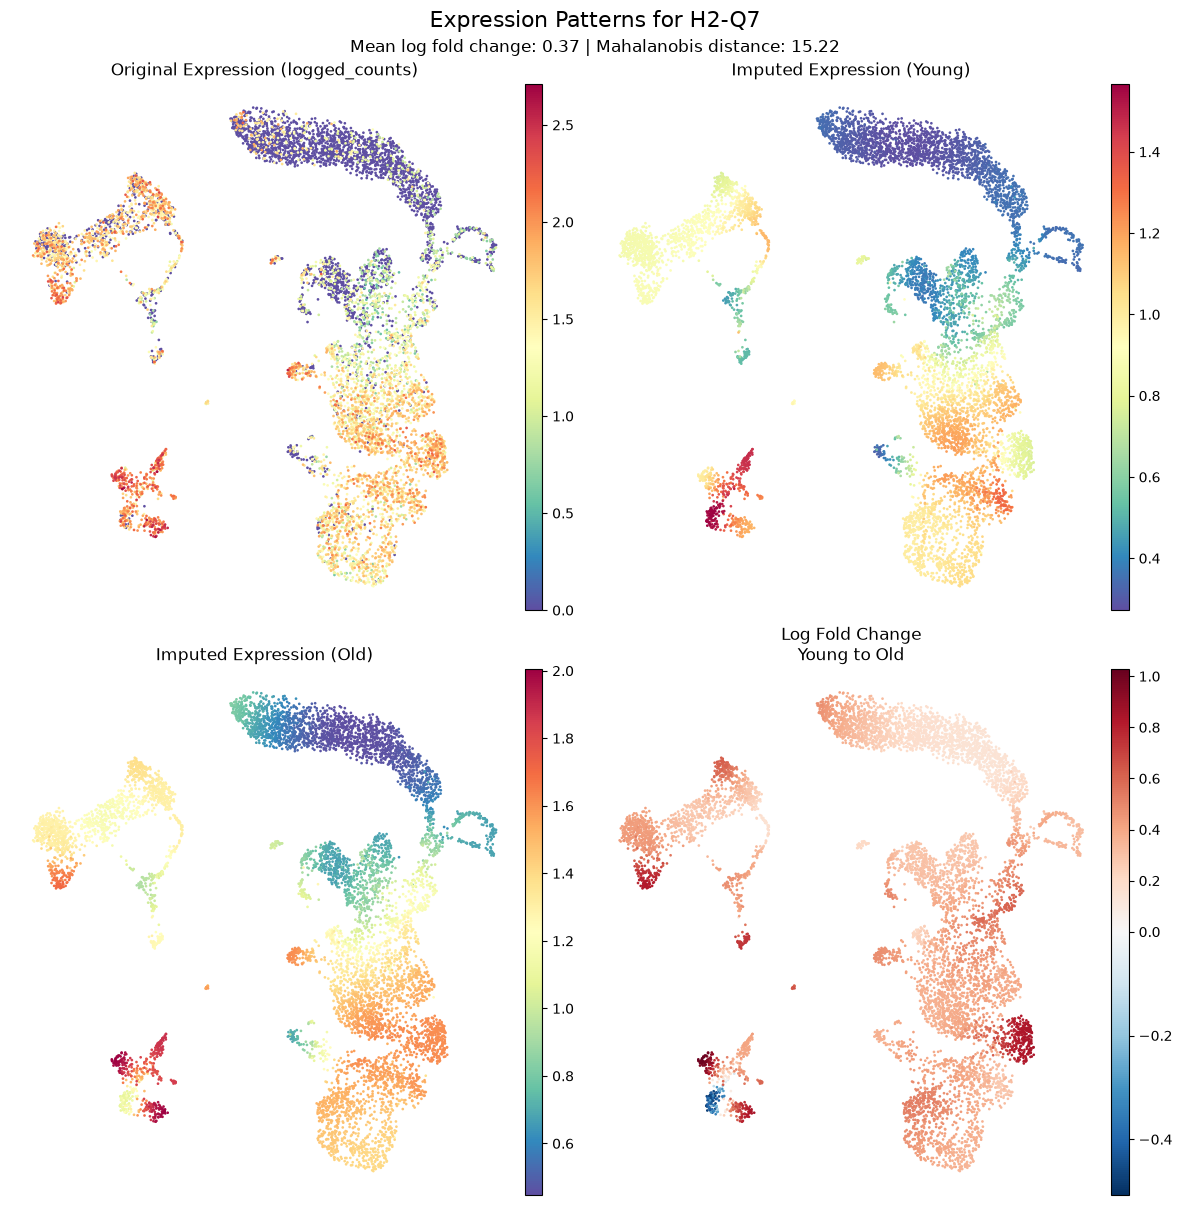

In [10]:
top_gene = adata.var[mahal].idxmax()
kompot.plot.plot_gene_expression(adata, gene=top_gene, frameon=False)

### Fold-change heatmap

The top genes summarized per cell type. `fold_change_mode=True` shows the
log fold change directly ([`heatmap`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.heatmap)):

[2026-07-11 00:56:50,819] [INFO    ] Inferred condition_column='Age' from run information


[2026-07-11 00:56:50,820] [INFO    ] Inferred condition1='Young' from run information


[2026-07-11 00:56:50,821] [INFO    ] Inferred condition2='Old' from run information


[2026-07-11 00:56:50,821] [INFO    ] Inferred layer='logged_counts' from run information


[2026-07-11 00:56:50,822] [INFO    ] Creating fold change heatmap with 20 genes/features


[2026-07-11 00:56:50,823] [INFO    ] Using expression data from layer: 'logged_counts'


[2026-07-11 00:56:50,927] [INFO    ] Excluded 7 cells from groups: Plasma cell


[2026-07-11 00:56:50,934] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


[2026-07-11 00:56:50,999] [WARNING ] standard_scale is ignored in fold_change_mode as z-scoring is not appropriate for fold changes


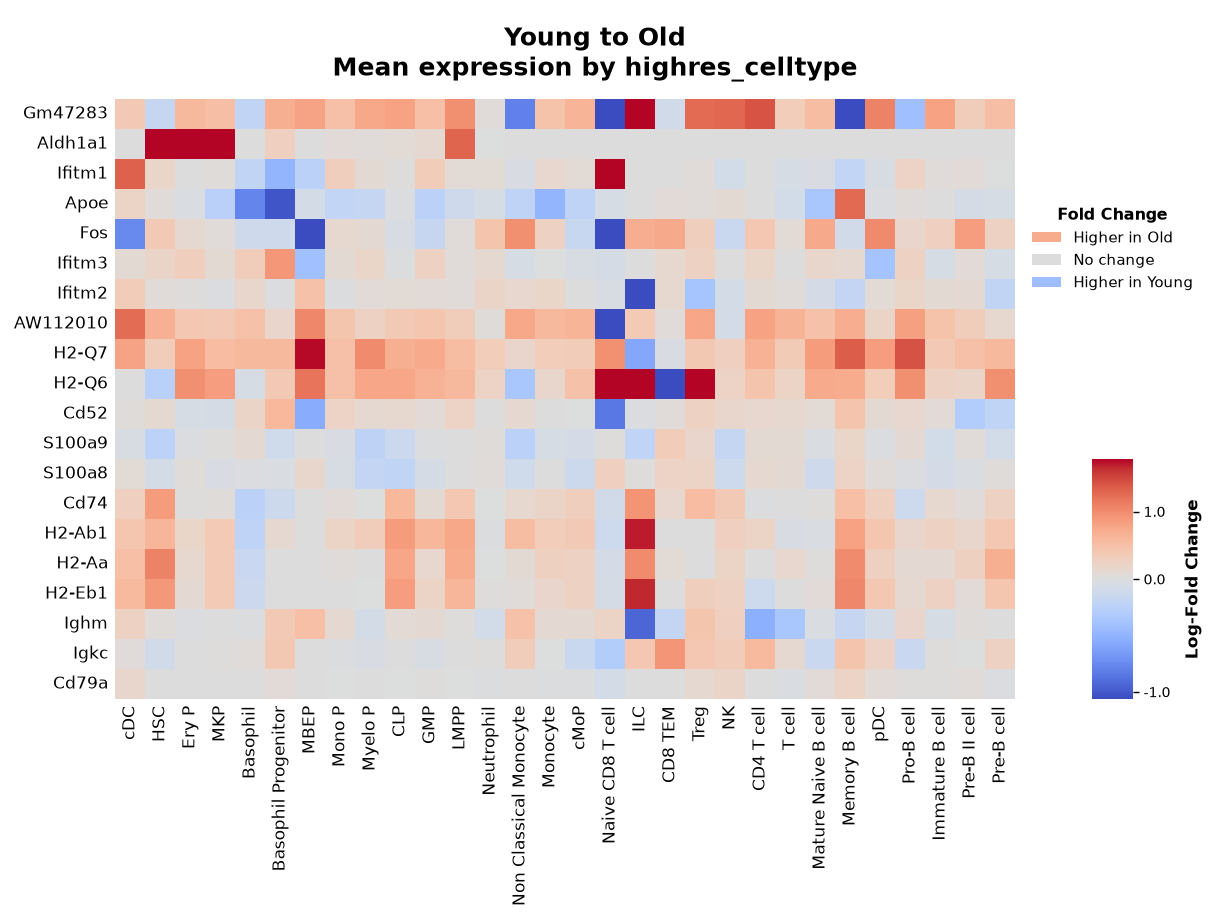

In [11]:
genes = adata.var[mahal].sort_values(ascending=False).head(20).index

kompot.plot.heatmap(
    adata,
    genes=genes,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",   # too few cells to summarize reliably
    vmin="p1", vmax="p99",          # clip color scale to 1st/99th percentile
    fold_change_mode=True,
)

### Fold-change dotplot

The same summary with a second dimension: **color** = mean log fold change,
**dot size** = fraction of cells expressing
([`dotplot`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.dotplot)):

[2026-07-11 00:56:52,176] [INFO    ] Found DE run info for run_id=-1


[2026-07-11 00:56:52,177] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-11 00:56:52,178] [INFO    ] Successfully inferred fields: {'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-11 00:56:52,179] [INFO    ] Using DE run 0 for heatmap.


[2026-07-11 00:56:52,179] [INFO    ] Inferred score_key='kompot_de_Young_to_Old_mahalanobis' from run information


[2026-07-11 00:56:52,184] [INFO    ] Using expression data from layer: 'kompot_de_Young_to_Old_fold_change'


[2026-07-11 00:56:52,203] [INFO    ] Using expression data from adata.X


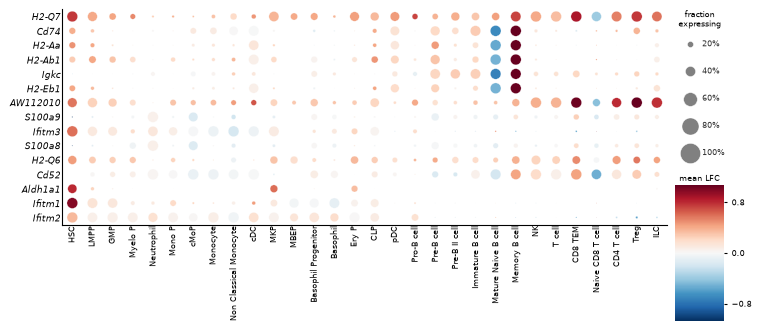

In [12]:
categories = [c for c in adata.obs[CELL_TYPE_COLUMN].cat.categories if c != "Plasma cell"]

kompot.plot.dotplot(
    adata,
    genes=None,          # auto-pick top genes by Mahalanobis
    groupby=CELL_TYPE_COLUMN,
    categories_order=categories,
    n_top=15,
)

### Functional enrichment

Send the significant genes to the [STRING database](https://string-db.org/) and
summarize enriched processes.

> **Privacy note:** this sends the gene list to an external API. For sensitive
> data, use a local enrichment tool instead.

In [13]:
sig_genes = adata.var_names[adata.var[f"kompot_de_{c1}_to_{c2}_is_de"]]

report = kompot.plot.StringDBReport(
    sig_genes,
    species_id=10090,               # 10090 = Mus musculus, 9606 = Homo sapiens
    include_enrichment=True,
    background=adata.var_names,      # test against measured genes, not the whole genome
)
report

[2026-07-11 00:57:09,404] [WARNING ] 2500 of 16285 identifiers could not be mapped to STRING IDs (e.g. 4732440D04Rik, Gm26901, 2610203C22Rik, 1700034P13Rik, Snhg6); they are excluded from the enrichment universe.


[2026-07-11 00:57:10,555] [WARNING ] 10 of 192 identifiers could not be mapped to STRING IDs (e.g. Trbc2, Igkc, Kcnq1ot1, Ighd, Ighm); they are excluded from the enrichment universe.


Gene,Resource Links
Cavin2,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Stat1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
C130026I21Rik,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Ramp1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Fcmr,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Btg2,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Rgs2,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Rgs18,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Ncf2,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Sell,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene


Turn the enriched terms into a compact lollipop plot ([`lollipop`](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.lollipop)):

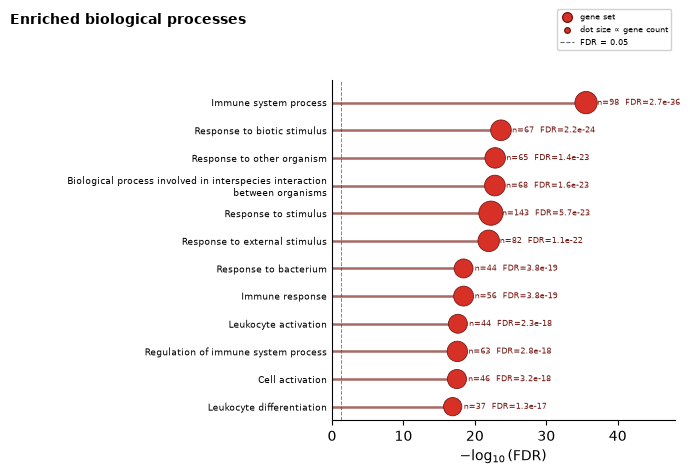

In [14]:
enrichment = report.get_functional_enrichment("Process")
kompot.plot.lollipop(enrichment, n_terms=12, title="Enriched biological processes")

### Run history

Kompot records every run's parameters and environment. Inspect the latest with
[`RunInfo`](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.anndata.utils.RunInfo):

In [15]:
kompot.RunInfo(adata, analysis_type="de")

Parameter,Value
conditions,Young to Old
obsm_key,DM_EigenVectors
uses_sample_variance,False
layer,logged_counts
timestamp,2026-07-11T00:56:48.400793
Fields Created,9
Parameter,Value
groupby,Age
condition1,Young
condition2,Old


### Save

Smoothed-expression layers are large; [`cleanup`](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.cleanup)
drops them while keeping the statistics in `adata.var`:

In [16]:
kompot.cleanup(adata)
adata.write_h5ad("../data/murine_bone_marrow_aging_processed.h5ad")

[2026-07-11 00:57:54,254] [INFO    ] Cleaning up all 1 run(s)


[2026-07-11 00:57:54,436] [INFO    ] Cleaned up 3 field(s) from run 0:


[2026-07-11 00:57:54,436] [INFO    ]   layers (3 field(s)):


[2026-07-11 00:57:54,437] [INFO    ]     - kompot_de_Young_smoothed


[2026-07-11 00:57:54,437] [INFO    ]     - kompot_de_Old_smoothed


[2026-07-11 00:57:54,438] [INFO    ]     - kompot_de_Young_to_Old_fold_change


[2026-07-11 00:57:54,438] [INFO    ] Total: Cleaned up 3 field(s) across 1 run(s)


## Where to go deeper

- **[Smoothing expression functions](./05_smooth_expression.ipynb)** — the GP estimator
  underneath DE: length scales, uncertainty, and training on a subset to transfer modalities
  or build counterfactuals.
- **[Advanced DE options](./02_differential_expression_detailed.ipynb)** — tuning (including
  `ls_factor`, which controls how smooth the expression function is), multiple comparisons,
  run tracking, resource planning.
- **[DE with sample variance](./03_sample_variance.ipynb)** — robust significance when you have
  biological replicates.
- **[Differential abundance](./04_differential_abundance.ipynb)** — find cell states that change
  in frequency.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** — the full method and derivation.
- **[Documentation](https://kompot.readthedocs.io)** — complete API reference.